In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

import ipywidgets as widgets
from IPython.display import display, clear_output

In [2]:
data_fake = pd.read_csv("Fake.csv")
data_true = pd.read_csv("True.csv")

data_fake["class"] = 0
data_true["class"] = 1

In [3]:
data_fake_manual = data_fake.tail(10)
data_true_manual = data_true.tail(10)

data_fake = data_fake.iloc[:-10]
data_true = data_true.iloc[:-10]

data_fake_manual.loc[:, 'class'] = 0
data_true_manual.loc[:, 'class'] = 1

In [4]:
data = pd.concat([data_fake, data_true], axis=0)
data = data.drop(['title', 'subject', 'date'], axis=1)

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

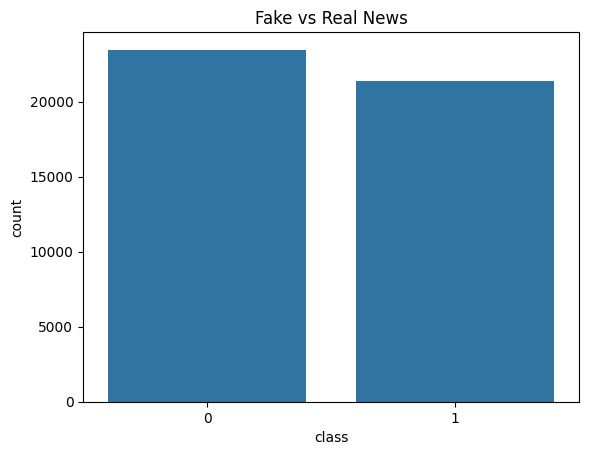

In [5]:
sns.countplot(x='class', data=data)
plt.title("Fake vs Real News")
plt.show()

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r"\W", " ", text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

data['text'] = data['text'].apply(clean_text)

In [7]:
x = data['text']
y = data['class']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

In [8]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

xv_train = vectorizer.fit_transform(x_train)
xv_test = vectorizer.transform(x_test)

In [9]:
LR = LogisticRegression(max_iter=1000)
LR.fit(xv_train, y_train)

DT = DecisionTreeClassifier(random_state=42)
DT.fit(xv_train, y_train)

GB = GradientBoostingClassifier(random_state=42)
GB.fit(xv_train, y_train)

RF = RandomForestClassifier(random_state=42)
RF.fit(xv_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
models = {
    "Logistic Regression": LR,
    "Decision Tree": DT,
    "Gradient Boosting": GB,
    "Random Forest": RF
}

for name, model in models.items():
    pred = model.predict(xv_test)
    print(f"\n{name} Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))


Logistic Regression Accuracy: 0.9854723707664884
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5900
           1       0.98      0.99      0.98      5320

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220


Decision Tree Accuracy: 0.9959001782531194
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5900
           1       1.00      0.99      1.00      5320

    accuracy                           1.00     11220
   macro avg       1.00      1.00      1.00     11220
weighted avg       1.00      1.00      1.00     11220


Gradient Boosting Accuracy: 0.9943850267379679
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      5900
           1       0.99      1.00      0.99      5320

    accuracy                           0

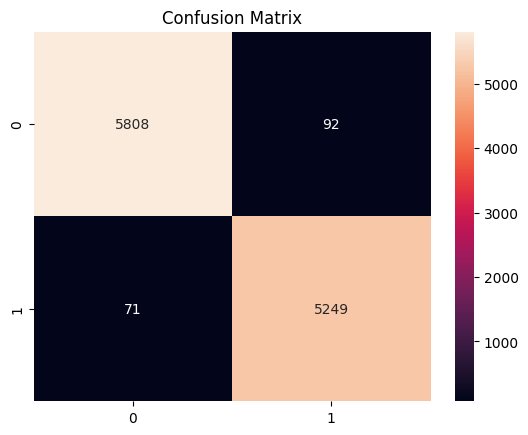

In [11]:
pred_lr = LR.predict(xv_test)

cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [12]:
def output_label(n):
    return "Fake News" if n == 0 else "Real News"

def manual_testing(news):
    news_df = pd.DataFrame({"text": [news]})
    news_df["text"] = news_df["text"].apply(clean_text)

    vector_input = vectorizer.transform(news_df["text"])

    pred = LR.predict(vector_input)
    print("Prediction:", output_label(pred[0]))

In [ ]:
text_input = widgets.Textarea(
    value='',
    placeholder='Enter news text here',
    description='News:',
    disabled=False,
    layout=widgets.Layout(width='100%', height='100px')
)

button = widgets.Button(description="Predict")

output = widgets.Output()

def on_button_clicked(b):
    with output:
        clear_output(wait=True)
        news = text_input.value
        if news.strip() == '':
            print("Please enter some text.")
            return
        news_df = pd.DataFrame({"text": [news]})
        news_df["text"] = news_df["text"].apply(clean_text)
        vector_input = vectorizer.transform(news_df["text"])
        pred = LR.predict(vector_input)
        print("Prediction:", output_label(pred[0]))

button.on_click(on_button_clicked)

display(text_input, button, output)